## Configuracion de Spark

In [1]:
## Se utiliza pyspark 3.5.1 y python 3.11

In [2]:
from pyspark.sql import SparkSession

In [3]:
spark = SparkSession.builder.appName("features").getOrCreate()

### Importacion de librerias

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from pyspark.sql import DataFrame
from pyspark.sql.functions import udf, col,count,lit

from pyspark.ml.stat import Correlation

from pyspark.sql.types import StringType, DateType

from pyspark.ml.feature import UnivariateFeatureSelector,StringIndexer,OneHotEncoder,VectorAssembler,StandardScaler,MinMaxScaler,QuantileDiscretizer
from pyspark.ml import Pipeline

from pyspark.ml.classification import (DecisionTreeClassifier,RandomForestClassifier,MultilayerPerceptronClassifier,
                                       NaiveBayes, LogisticRegression,GBTClassifier,LinearSVC,FMClassifier)
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

## Feature Selection

### 1. INDEXACIÓN DE LA VARIABLE OBJETIVO (TARGET)

In [5]:
## En caso mi variable sea del tipo categorico
def label_indexed(df: DataFrame,col_label:str):
    """
    Indexa la columna objetivo convirtiéndola en valores numéricos estables (0 y 1).
    Usa 'handleInvalid=keep' para evitar caídas por valores inesperados.
    """
    
    indexer_lbl = StringIndexer(inputCol=col_label, outputCol=f'{col_label}_idx', handleInvalid='keep')
    
    # Renombramos temporalmente para mantener consistencia en los tipos de datos
    
    df_l = indexer_lbl.fit(df).transform(df).withColumnRenamed(col_label,f'{col_label}_cat')\
                    .withColumnRenamed(f'{col_label}_idx',f'{col_label}')
    return df_l

### 2. SEPARACIÓN AUTOMÁTICA DE COLUMNAS POR TIPO DE DATOS

In [6]:
def division_columnas(df: DataFrame, col_label: str = 'label'):
    cols_categoricas = [c.name for c in df.schema 
                    if (c.dataType==StringType()) & (c.name!=col_label) & (c.name!=col_label+'_cat')]
    
    cols_nums = [c.name for c in df.schema 
             if (c.dataType.simpleString() in ('int', 'bigint', 'double', 'float', 'decimal', 'long', 'short')) 
                 & (c.name!=col_label)  & (c.name!=col_label+'_cat')]
    
    return cols_categoricas, cols_nums

### 3. ANÁLISIS DE MULTICOLINEALIDAD (MATRIZ DE CORRELACIÓN DE PEARSON)

In [7]:
def get_multicolinealidad(df: DataFrame, cols_nums: list):
    
    """
    Calcula la correlación cruzada entre variables numéricas.
    Si dos variables superan un umbral del 90% (0.90), marca una de ellas para remoción
    con el fin de evitar redundancias que afecten la Regresión Logística y SVM.
    """
    
    # Spark requiere empaquetar las variables en un vector antes de calcular la matriz
    num_assembler = VectorAssembler(inputCols = cols_nums, outputCol='num_vec')
    
    df_num = num_assembler.transform(df).select('num_vec')
    
    # Extracción de la matriz de correlación en formato Array de NumPy
    corr_mat = Correlation.corr(df_num, "num_vec", "pearson").head()[0].toArray()
    
    to_drop = set()
    for i in range(len(cols_nums)):
        for j in range(i+1, len(cols_nums)):
            if abs(corr_mat[i, j]) > 0.90:
                to_drop.add(cols_nums[j])
    
    # Filtrado: Retorna variables limpias, variables descartadas y la matriz completa
    num_cols_filtered = [c for c in cols_nums if c not in to_drop]
    return num_cols_filtered,sorted(list(to_drop)),corr_mat

### 4. SELECCIÓN DE CARACTERÍSTICAS (ANOVA / CHI-CUADRADO AUTOMATIZADO)

In [8]:
# ------------------------------------------------------------------------------
# Esta función utiliza selectores univariados para aplicar
# filtros estadísticos de significancia basados en p-value (Umbral por defecto: 0.05)

In [9]:
def get_cols_selected(df: DataFrame,featureTypeCat: bool, cols: list, 
            label_col: str ='label', threshold:float =0.05, mode: str = 'fpr'):
    
    featType=''
    
    if featureTypeCat:
        # Si la variable es categórica, aplicamos Chi-Cuadrado de independencia
        
        cat_indexers = [StringIndexer(inputCol=c, outputCol=f'{c}_idx', handleInvalid='keep') for c in cols]
    
        for ix in cat_indexers:
            df = ix.fit(df).transform(df)
        cols_vec = [f'{c}_idx' for c in cols]
        featType = 'categorical'
        
    else:
        # Si la variable es numérica/continua, el selector aplicará la prueba ANOVA
        
        cols_vec = cols
        featType = 'continuous'
    
    # Empaquetamos en vectores para la lectura del Selector de Spark
    
    assembler = VectorAssembler(inputCols=cols_vec, outputCol='vec')
    df_assembler = assembler.transform(df)
        
    # Configuración estricta de tipos de entrada para pruebas estadísticas
    
    df_sel = UnivariateFeatureSelector(
        featuresCol="vec",
        labelCol=label_col,
        selectionMode=mode,
        outputCol="selectedFeatures"
    )
    
    df_sel.setFeatureType(featType).setLabelType("categorical").setSelectionThreshold(threshold)

    sel_model = df_sel.fit(df_assembler)
    df_selected = sel_model.transform(df_assembler)
    cols_sel = [cols[i] for i in sel_model.selectedFeatures]
    return cols_sel

## Uso de Funciones

In [10]:
df = spark.read.csv('customer_churn_data.csv', inferSchema = True, sep =',', header= True)

In [11]:
df = label_indexed(df,'churn')

In [12]:
cat_col, num_cols = division_columnas(df,'churn')

In [13]:
num_cols_filtered,to_drop,corr_mat = get_multicolinealidad(df, num_cols)

In [14]:
cat_cols_selected = get_cols_selected(df,True,cat_col,'churn')

In [15]:
num_cols_selected = get_cols_selected(df,False,num_cols_filtered,'churn')

In [16]:
clean_df  =  df.select(*cat_cols_selected, *num_cols_selected,'churn_cat').withColumnRenamed("churn_cat","churn")

In [17]:
df.printSchema()

root
 |-- id_cliente: integer (nullable = true)
 |-- edad: integer (nullable = true)
 |-- ingreso_anual: double (nullable = true)
 |-- meses_antiguedad: integer (nullable = true)
 |-- plan_servicio: string (nullable = true)
 |-- soporte_tecnico_llamadas: integer (nullable = true)
 |-- metodo_pago: string (nullable = true)
 |-- gasto_anual: double (nullable = true)
 |-- churn_cat: integer (nullable = true)
 |-- churn: double (nullable = false)



In [18]:
clean_df.printSchema()

root
 |-- plan_servicio: string (nullable = true)
 |-- soporte_tecnico_llamadas: integer (nullable = true)
 |-- edad: integer (nullable = true)
 |-- meses_antiguedad: integer (nullable = true)
 |-- churn: integer (nullable = true)



### Conclusión del Proceso de Selección de Características (Feature Selection)

El dataset inicial constaba de un total de 9 variables independientes para predecir la variable objetivo (`churn`). Con el objetivo de optimizar el espacio de características y evitar introducir ruido o sesgos en los modelos matemáticos, se aplicó un riguroso pipeline estadístico en tres etapas:

1. **Control de Multicolinealidad:** Mediante el cálculo de la **Matriz de Correlación de Pearson**, se detectaron pares de variables numéricas altamente correlacionadas (con un coeficiente superior al 90%). Como resultado, se identificó redundancia severa entre `ingreso_anual` y `gasto_anual`, procediendo a descartar la variable redundante para proteger la estabilidad de algoritmos lineales como la Regresión Logística y SVM.

2. **Filtro de Significancia Estadística (ANOVA y $\chi^2$):** Con las variables remanentes, se utilizaron selectores univariados (`UnivariateFeatureSelector`) bajo un enfoque de Tasa de Falsos Positivos (FPR):
   * Se aplicó la prueba de **Chi-Cuadrado ($\chi^2$)** para evaluar la independencia de los atributos categóricos.
   * Se aplicó la prueba **ANOVA** para evaluar la diferencia de medias en los atributos numéricos continuos.

**Resultado Final:** Solo aquellas variables con un **p-value < 0.05** (nivel de significancia del 5%) demostraron tener un impacto real y estadísticamente significativo sobre el target. El espacio original se redujo con éxito a las 4 variables más potentes (`plan_servicio`, `soporte_tecnico_llamadas`, `edad` y `meses_antiguedad`), garantizando un modelo final más parsimónico, eficiente y libre de variables irrelevantes o redundantes.

##  Feature Engineering

In [19]:
from pyspark.ml.feature import StringIndexer,OneHotEncoder
from pyspark.ml import Pipeline

In [20]:
train_df, test_df = clean_df.randomSplit([0.8, 0.2], seed=700)

In [21]:
# Procesamiento Categórico: Conversión de String a Índice y posterior codificación

In [22]:
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx") for c in cat_cols_selected]
encoder = OneHotEncoder(
    inputCols=[f"{c}_idx" for c in cat_cols_selected],
    outputCols=[f"{c}_vec" for c in cat_cols_selected]
)

In [23]:
# Procesamiento Numérico: Ensamblado y estandarización obligatoria

In [24]:
num_assembler = VectorAssembler(inputCols=num_cols_selected, outputCol="num_features")
scaler = StandardScaler(inputCol="num_features", 
                        outputCol="num_scaled",
                        withMean=True,
                        withStd=True)

# Ensamblado Final: Unificación del vector numérico estandarizado y el vector categórico codificado
cat_assembler = VectorAssembler(inputCols=[f"{c}_vec" for c in cat_cols_selected], outputCol="cat_features")

final_assembler = VectorAssembler(inputCols=["num_scaled", "cat_features"], outputCol="features_scaled")

In [25]:
# Definición jerárquica 
pipeline = Pipeline(stages=indexers + [encoder,num_assembler, scaler, cat_assembler,final_assembler])

In [26]:
#Ejecucion del Pipeline

model = pipeline.fit(train_df)
train_scaled = model.transform(train_df)
test_scaled = model.transform(test_df)

In [27]:
train_scaled.select("churn",'features_scaled').show(6,truncate=False)

+-----+---------------------------------------------------------------------+
|churn|features_scaled                                                      |
+-----+---------------------------------------------------------------------+
|0    |[-1.4974796896696443,-1.7330680325775556,-1.6852350117426915,1.0,0.0]|
|0    |[-1.4974796896696443,-1.7330680325775556,-1.2850007122627667,1.0,0.0]|
|0    |[-1.4974796896696443,-1.7330680325775556,0.44934791881690833,1.0,0.0]|
|0    |[-1.4974796896696443,-1.7330680325775556,1.427698428656725,1.0,0.0]  |
|0    |[-1.4974796896696443,-1.6718991018391745,0.49381839653689996,1.0,0.0]|
|0    |[-1.4974796896696443,-1.610730171100793,-0.6624140241828833,1.0,0.0] |
+-----+---------------------------------------------------------------------+
only showing top 6 rows



## Modelamiento, Configuración y Validación

In [28]:
etiqueta = "churn"

In [29]:
dt = DecisionTreeClassifier(featuresCol="features_scaled", labelCol=etiqueta, maxDepth=5, seed = 700)
dt_model = dt.fit(train_scaled)
dt_pred = dt_model.transform(test_scaled)

In [30]:
rf = RandomForestClassifier(featuresCol="features_scaled", labelCol=etiqueta, numTrees=100 , seed = 700)
rf_model = rf.fit(train_scaled)

rf_pred = rf_model.transform(test_scaled)

In [31]:
# Estructura adaptativa de capas: [Entradas, Capa_Oculta_1, Capa_Oculta_2, Clases_Salida]
layers = [len(train_scaled.select("features_scaled").first()[0]), 10, 5, df.select(etiqueta).distinct().count()]
mlp = MultilayerPerceptronClassifier(featuresCol="features_scaled", labelCol=etiqueta, layers=layers, seed=700)
mlp_model = mlp.fit(train_scaled)

mlp_pred = mlp_model.transform(test_scaled)

In [32]:
lr = LogisticRegression(featuresCol="features_scaled", labelCol=etiqueta)
lr_model = lr.fit(train_scaled)

lr_pred = lr_model.transform(test_scaled)

In [33]:
gbt = GBTClassifier(
    featuresCol="features_scaled",  
    labelCol=etiqueta,          
    maxIter=50,
    maxDepth=5,
    stepSize=0.1,
    subsamplingRate=1.0,
    seed=700
)

gbt_model = gbt.fit(train_scaled)

gbt_pred = gbt_model.transform(test_scaled)

In [34]:
fm = FMClassifier(
    featuresCol="features_scaled", 
    labelCol=etiqueta,
    factorSize=8,
    stepSize=0.1,
    regParam=0.001,
    maxIter=100,
    seed=700
)

fm_model = fm.fit(train_scaled)
fm_pred  = fm_model.transform(test_scaled)

In [35]:
svm = LinearSVC(
    featuresCol="features_scaled",
    labelCol=etiqueta,
    maxIter=100,
    regParam=0.01,
    fitIntercept=True,
    standardization=False
)
svm_model = svm.fit(train_scaled)
svm_pred = svm_model.transform(test_scaled)

## Metricas

In [36]:
multi_eval = MulticlassClassificationEvaluator(labelCol=etiqueta, predictionCol="prediction")
bin_eval   = BinaryClassificationEvaluator(labelCol=etiqueta, rawPredictionCol="rawPrediction", metricName="areaUnderROC")

metrics = [
    ("accuracy", "Accuracy"),
    ("f1", "F1-score"),
    ("weightedPrecision", "Precision (weighted)"),
    ("weightedRecall", "Recall (weighted)"),
]

print(f"{'Modelo':20s} | Accuracy|F1-score |Precision| Recall  | AUC")
print("-"*70)

for name, pred in [
    ("DecisionTree", dt_pred),
    ("RandomForest", rf_pred),
    ("MLP", mlp_pred),
    ("LogisticRegression", lr_pred),
    ("GBT", gbt_pred),
    ("FMC", fm_pred),
    ("SVM", svm_pred)
]:
    results = {}
    for metric_key, label in metrics:
        results[metric_key] = multi_eval.setMetricName(metric_key).evaluate(pred)
    try:
        auc = bin_eval.evaluate(pred)
    except Exception:
        auc = float('nan')

    print(f"{name:20s} | {results['accuracy']:.3f}   | {results['f1']:.3f}   | {results['weightedPrecision']:.3f}   | {results['weightedRecall']:.3f}   | {auc:.3f}")

Modelo               | Accuracy|F1-score |Precision| Recall  | AUC
----------------------------------------------------------------------
DecisionTree         | 0.907   | 0.907   | 0.907   | 0.907   | 0.926
RandomForest         | 0.924   | 0.924   | 0.924   | 0.924   | 0.984
MLP                  | 0.998   | 0.998   | 0.998   | 0.998   | 1.000
LogisticRegression   | 1.000   | 1.000   | 1.000   | 1.000   | 1.000
GBT                  | 0.966   | 0.966   | 0.966   | 0.966   | 0.995
FMC                  | 0.989   | 0.989   | 0.989   | 0.989   | 0.999
SVM                  | 0.977   | 0.977   | 0.977   | 0.977   | 0.999


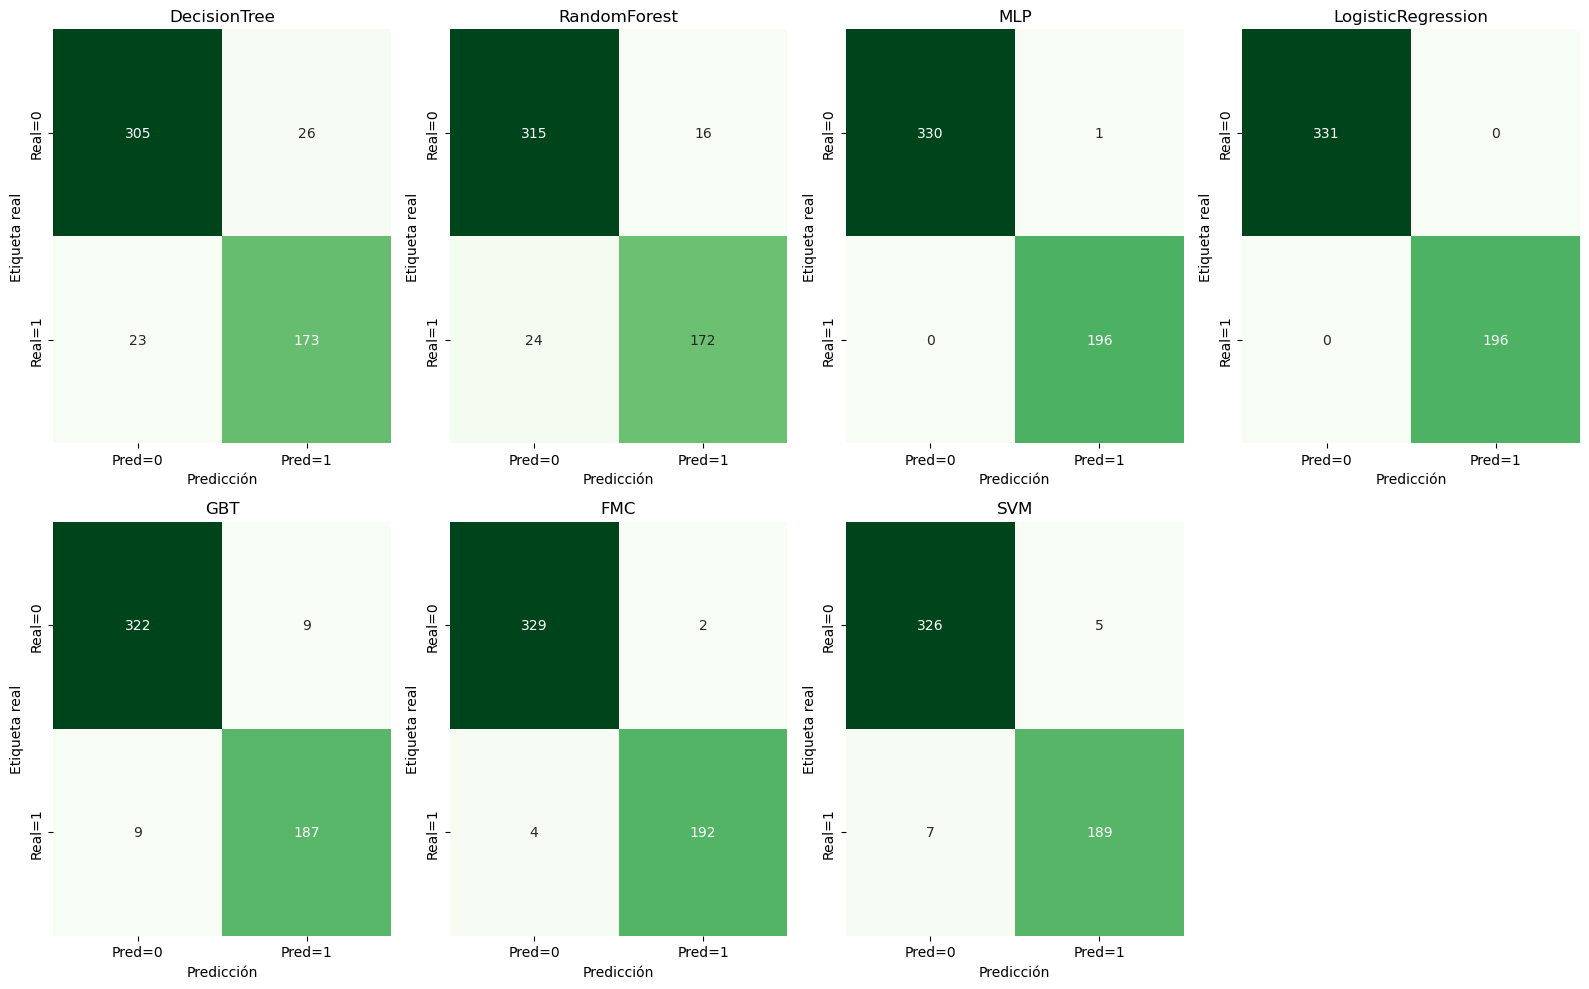

In [37]:
def get_confusion_matrix(pred_df, label_col=etiqueta, pred_col="prediction"):
    cm = (pred_df
          .groupBy(label_col, pred_col)
          .agg(count(lit(1)).alias("count"))
          .toPandas().pivot(index=label_col, columns=pred_col, values="count")
          .fillna(0).astype(int))
    cm = cm.reindex(index=[0.0,1.0], columns=[0.0,1.0], fill_value=0)
    return cm.values 

preds = {
    "DecisionTree": dt_pred,
    "RandomForest": rf_pred,
    "MLP": mlp_pred,
    "LogisticRegression": lr_pred,
    "GBT": gbt_pred,
    "FMC": fm_pred,
    "SVM": svm_pred
}

plt.figure(figsize=(16,10))

for i, (name, pdf) in enumerate(preds.items(), 1):
    cm = get_confusion_matrix(pdf)
    plt.subplot(2,4,i)  
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False,
                xticklabels=["Pred=0", "Pred=1"],
                yticklabels=["Real=0", "Real=1"])
    plt.title(name)
    plt.ylabel("Etiqueta real")
    plt.xlabel("Predicción")

plt.tight_layout()
plt.show()


## Conclusion

Al analizar los resultados obtenidos con los datos de prueba, observamos que algunos modelos alcanzaron niveles de precisión inusualmente altos para un problema de predicción de abandono de clientes (churn). La Regresión Logística obtuvo un Accuracy de 1.000 y el MLP de 0.998, mientras que Random Forest y Decision Tree alcanzaron valores de 0.924 y 0.907 respectivamente.

Aunque a primera vista estos resultados podrían parecer excelentes, consideramos que deben analizarse con cautela. En problemas relacionados con el comportamiento humano es poco común obtener niveles de precisión cercanos al 100%, ya que las decisiones de los clientes suelen estar influenciadas por múltiples factores difíciles de predecir. Por ello, estos resultados podrían indicar la presencia de sobreajuste (overfitting) o incluso una fuga de datos (data leakage), donde el modelo estaría utilizando información que no debería estar disponible durante la predicción.

En conclusión, antes de considerar estos modelos como una solución confiable, sería necesario revisar la calidad de los datos, el proceso de preparación y la forma en que se realizó la partición entre entrenamiento y prueba, para asegurar que los resultados reflejen realmente la capacidad de generalización del modelo.